<a href="https://colab.research.google.com/github/Aldyth11/PCVK_Ganjil_2026/blob/main/Week3_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import datetime
import hashlib
import platform
import sys
import zoneinfo

NAMA = 'M. Aldyth Rafiansyah Fauzi'
NIM = '244107020179'  # NIM Anda

N = int(NIM[-3:])
PARAM = {
    'b': (N % 61) + 20,
    'a': round(1.0 + (N % 9) / 10, 1),
    'c': (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit': (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM  :', NIM, f'| N = {N}')
for k, v in PARAM.items():
    print('%-6s :%s' % (k, v))
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : M. Aldyth Rafiansyah Fauzi
NIM  : 244107020179 | N = 179
b      :77
a      :1.8
c      :49
gamma  :1.65
bit    :7
WAKTU : 2026-09-15 14:21:24 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 1611decc9d85f9a2


**Transformasi Linier Brightness**

> Formula: g(x,y)=f(x,y)+b

g(x,y) adalah nilai pixel setelah transformasi, f(x,y) adalah nilai pixel asli, b adalah nilai brightness

In [62]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

 Mengubah tingkat kecerahan citra
---------------------------------
Masukkan nilai kecerahan: 20


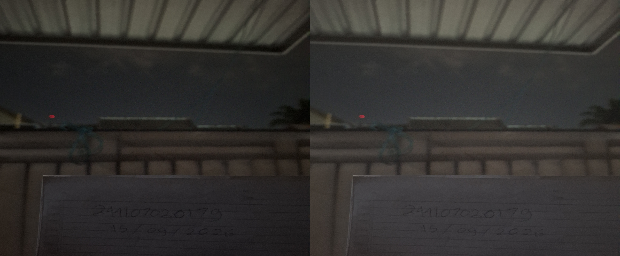

In [64]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra')
print('---------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK2026/NIGHT1.jpg')
# Resize original ke (310, 256)
original = cv.resize(original, (310, 256))

brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
# for y in range(original.shape[0]):
#   for x in range(original.shape[1]):
#     for c in range(original.shape[2]):
#       brightness_image[y,x,c] = np.clip(original [y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
brightness_image = cv.convertScaleAbs(original, beta=brightness) #-Transformasi Linier Brightness

final_frame = cv.hconcat ((original, brightness_image))
cv2_imshow(final_frame)

TUGAS PRAKTIKUM

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula pada
bagian Ulasan Teori. Terapkan pada KTM1b.jpg dan KTM1a.jpg, tampilkan
berdampingan dengan citra aslinya. Jelaskan mengapa citra negatif dari KTM1a
(ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap
kontras.

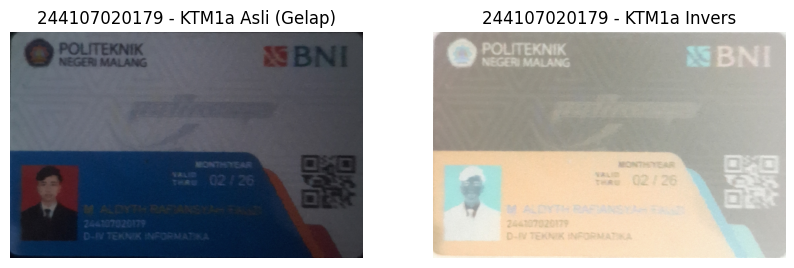

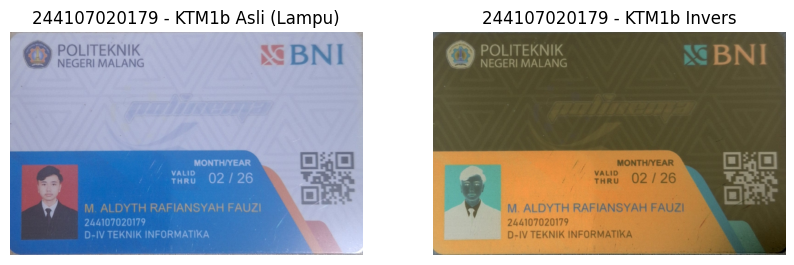

In [4]:
import cv2
import matplotlib.pyplot as plt

path_a = f'/content/drive/MyDrive/PCVK2026/KTM1a.jpg'
path_b = f'/content/drive/MyDrive/PCVK2026/KTM1b.jpg'

# Membaca citra dan konversi dari BGR (OpenCV) ke RGB (Matplotlib)
img_a = cv2.cvtColor(cv2.imread(path_a), cv2.COLOR_BGR2RGB)
img_b = cv2.cvtColor(cv2.imread(path_b), cv2.COLOR_BGR2RGB)

# Formula invers citra (Citra Negatif)
# Formula: s = 255 - r
inv_a = 255 - img_a
inv_b = 255 - img_b

# Menampilkan citra berdampingan untuk KTM1a (Asli vs Invers)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_a)
plt.title(f'{NIM} - KTM1a Asli (Gelap)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inv_a)
plt.title(f'{NIM} - KTM1a Invers')
plt.axis('off')

plt.show()

# Menampilkan citra berdampingan untuk KTM1b (Asli vs Invers)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_b)
plt.title(f'{NIM} - KTM1b Asli (Lampu)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inv_b)
plt.title(f'{NIM} - KTM1b Invers')
plt.axis('off')

plt.show()

2. Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda
(PARAM['a']) pada KTM1a.jpg.

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.8


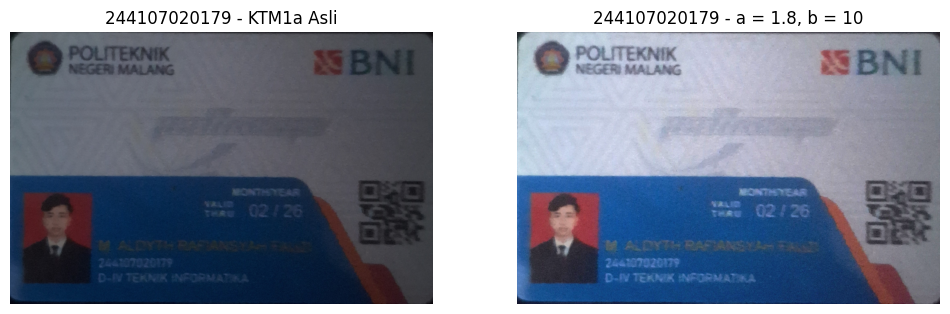

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("Mengubah kontras dan tingkat kecerahan citra")
print("-" * 50)

tingkat_kecerahan = float(input("Masukkan tingkat kecerahan : "))

kontras_a = PARAM['a']
print(f"Masukkan kontras : {kontras_a}")

path_a = '/content/drive/MyDrive/PCVK2026/KTM1a.jpg'
img_asli = cv2.cvtColor(cv2.imread(path_a), cv2.COLOR_BGR2RGB)

# Proses transformasi kontras dan kecerahan (Rumus: s = a * r + b)
img_hasil = cv2.multiply(img_asli.astype(np.float32), kontras_a)
img_hasil = cv2.add(img_hasil, tingkat_kecerahan)
img_hasil = np.clip(img_hasil, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_asli)
plt.title(f'{NIM} - KTM1a Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_hasil)
plt.title(f'{NIM} - a = {kontras_a}, b = {int(tingkat_kecerahan)}')
plt.axis('off')

plt.show()

3. Implementasikan transformasi logarithmic brightness dengan konstanta c hasil hitung
dari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightness
memakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama. Tentukan
metode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan
bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.

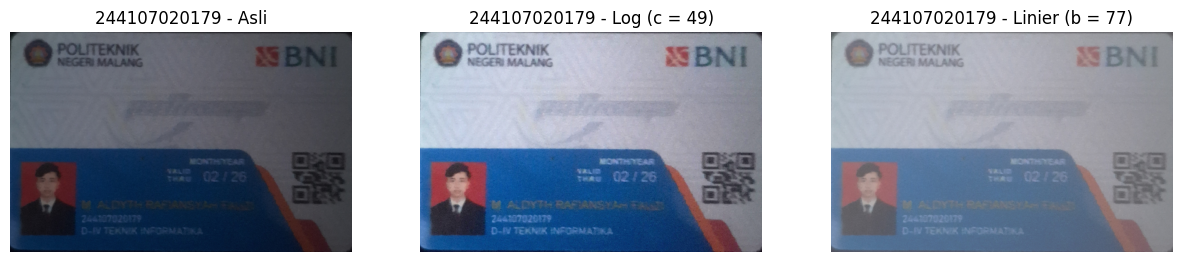

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

path_a = '/content/drive/MyDrive/PCVK2026/KTM1a.jpg'
img_asli = cv2.cvtColor(cv2.imread(path_a), cv2.COLOR_BGR2RGB)

c_val = PARAM['c']
b_val = PARAM['b']

# Rumus Log Brightness: s = c * log(1 + r)
img_float = img_asli.astype(np.float32) / 255.0
img_log = c_val * np.log(1 + img_float)
img_log = cv2.normalize(img_log, None, 0, 255, cv2.NORM_MINMAX)
img_log = np.clip(img_log, 0, 255).astype(np.uint8)

# Rumus Linier Brightness: s = r + b
img_linier = cv2.add(img_asli.astype(np.float32), b_val)
img_linier = np.clip(img_linier, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_asli)
plt.title(f'{NIM} - Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_log)
plt.title(f'{NIM} - Log (c = {c_val})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_linier)
plt.title(f'{NIM} - Linier (b = {b_val})')
plt.axis('off')

plt.show()

4. Implementasikan transformasi grayscale metode averaging, lightness, dan luminance
pada KTM1c.jpg, yaitu citra yang diambil dengan flash. Hitung rata-rata dan
simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan
metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.

Tabel Statistik Intensitas Citra Grayscale:


,Metode,Rata-rata (Mean),Simpangan Baku (Std)
0,Averaging,160.819842,39.442768
1,Lightness,162.639114,38.395880
2,Luminance,156.520106,42.241707


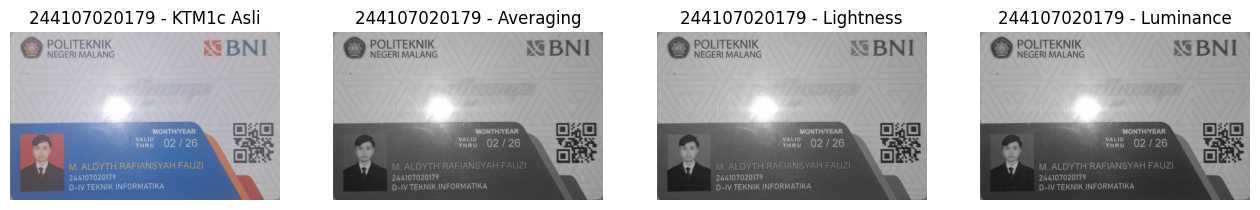

In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

path_c = '/content/drive/MyDrive/PCVK2026/KTM1c.jpg'
img_asli = cv2.cvtColor(cv2.imread(path_c), cv2.COLOR_BGR2RGB)

# Ambil komponen channel R, G, dan B
R = img_asli[:, :, 0].astype(np.float32)
G = img_asli[:, :, 1].astype(np.float32)
B = img_asli[:, :, 2].astype(np.float32)

# a. Averaging
img_avg = np.clip((R + G + B) / 3.0, 0, 255).astype(np.uint8)

# b. Lightness
max_rgb = np.maximum(np.maximum(R, G), B)
min_rgb = np.minimum(np.minimum(R, G), B)
img_light = np.clip((max_rgb + min_rgb) / 2.0, 0, 255).astype(np.uint8)

# c. Luminance
img_lum = np.clip(0.299 * R + 0.587 * G + 0.114 * B, 0, 255).astype(np.uint8)

# Hitung Rata-rata (Mean) dan Simpangan Baku (Standard Deviation)
stats = {
    'Metode': ['Averaging', 'Lightness', 'Luminance'],
    'Rata-rata (Mean)': [np.mean(img_avg), np.mean(img_light), np.mean(img_lum)],
    'Simpangan Baku (Std)': [np.std(img_avg), np.std(img_light), np.std(img_lum)]
}

df_stats = pd.DataFrame(stats)
print("Tabel Statistik Intensitas Citra Grayscale:")
display(df_stats)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_asli)
plt.title(f'{NIM} - KTM1c Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_avg, cmap='gray')
plt.title(f'{NIM} - Averaging')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_light, cmap='gray')
plt.title(f'{NIM} - Lightness')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_lum, cmap='gray')
plt.title(f'{NIM} - Luminance')
plt.axis('off')

plt.show()

5. Tampilkan satu warna tertentu pada citra dan ubah bagian lainnya menjadi grayscale.
Gunakan OBJ1.jpg, yaitu foto benda milik Anda sendiri dengan satu warna dominan.
Sebutkan rentang nilai HSV yang Anda pakai sebagai batas warna, lalu tunjukkan
pengaruhnya apabila rentang tersebut diperlebar dan dipersempit.

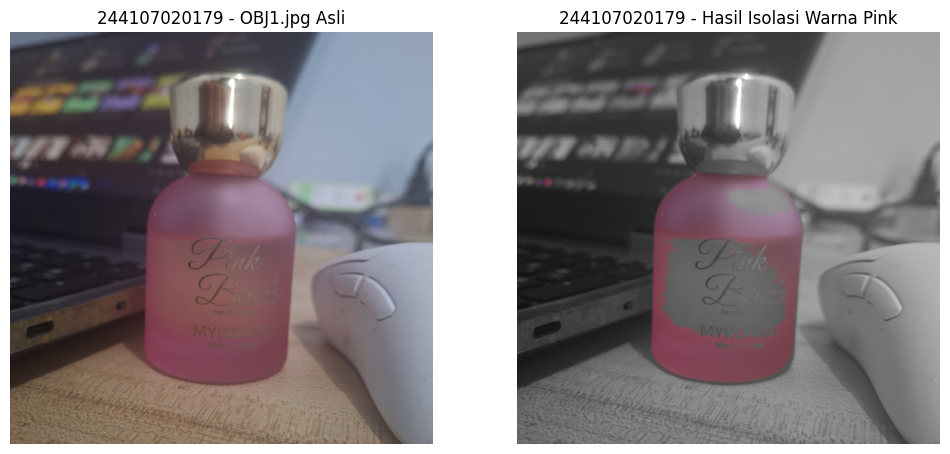

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

path_obj = '/content/drive/MyDrive/PCVK2026/OBJ1.jpg'
img_bgr = cv2.imread(path_obj)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Rentang HSV untuk warna Pink/Merah Muda pada botol
# (Hue untuk pink/magenta di OpenCV biasanya sekitar 140-175)
lower_bound = np.array([140, 50, 80])   # Batas bawah
upper_bound = np.array([175, 255, 255])  # Batas atas

# Buat Mask (Pemisahan area warna target)
mask = cv2.inRange(img_hsv, lower_bound, upper_bound)

# Ubah seluruh citra asli menjadi Grayscale (3 channel)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_gray_3ch = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

# Gabungkan objek pink asli dengan latar belakang yang sudah grayscale
target_color = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
inv_mask = cv2.bitwise_not(mask)
background_gray = cv2.bitwise_and(img_gray_3ch, img_gray_3ch, mask=inv_mask)
result_img = cv2.add(target_color, background_gray)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(f'{NIM} - OBJ1.jpg Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_img)
plt.title(f'{NIM} - Hasil Isolasi Warna Pink')
plt.axis('off')

plt.show()

6. Nilai gamma diminta dari pengguna melalui kode di bawah ini. Lanjutkan kode tersebut
sesuai rumus pada Ulasan Teori, kemudian terapkan pada KTM1a.jpg. Mulailah dari nilai
gamma hasil hitung dari NIM Anda, lalu cari secara bertahap nilai gamma yang membuat
NIM dan nama pada kartu paling terbaca. Tampilkan minimal lima nilai gamma yang dicoba beserta hasilnya, sebutkan nilai gamma terbaik pilihan Anda, dan jelaskan
mengapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma (Rekomendasi NIM = 1.65): 0.5


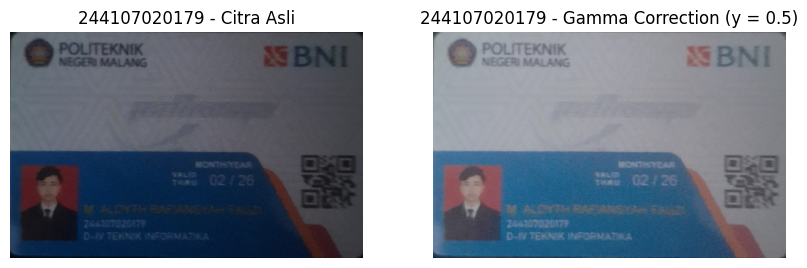

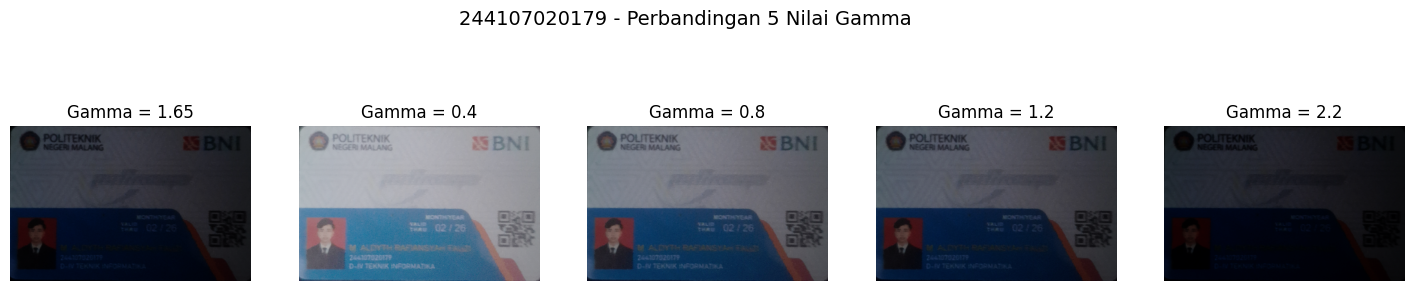

In [31]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

path_a = '/content/drive/MyDrive/PCVK2026/KTM1a.jpg'
img_asli = cv2.cvtColor(cv2.imread(path_a), cv2.COLOR_BGR2RGB)

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    # Menggunakan float() agar bisa menerima angka desimal (seperti 1.65)
    gamma_input = float(input(f'Masukkan nilai Gamma (Rekomendasi NIM = {PARAM["gamma"]}): '))
except ValueError:
    print('Error, not a number. Menggunakan nilai default dari NIM.')
    gamma_input = PARAM['gamma']

def apply_gamma(image, gamma):
    img_float = image.astype(np.float32) / 255.0
    # Rumus Gamma Correction: s = r^gamma
    img_gamma = np.power(img_float, gamma)
    img_gamma = np.clip(img_gamma * 255.0, 0, 255).astype(np.uint8)
    return img_gamma

img_hasil_input = apply_gamma(img_asli, gamma_input)

# Tampilkan hasil input utama
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_asli)
plt.title(f'{NIM} - Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_hasil_input)
plt.title(f'{NIM} - Gamma Correction (y = {gamma_input})')
plt.axis('off')
plt.show()

list_gamma = [PARAM['gamma'], 0.4, 0.8, 1.2, 2.2]

plt.figure(figsize=(18, 4))
for i, g in enumerate(list_gamma):
    img_g = apply_gamma(img_asli, g)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img_g)
    plt.title(f'Gamma = {g}')
    plt.axis('off')

plt.suptitle(f'{NIM} - Perbandingan 5 Nilai Gamma', fontsize=14)
plt.show()

> Nilai gamma terbaik untuk KTM1a.jpg bberada di kisaran angka 0.4 sampai 0.8. Dengan nilai di bawah 1, kurva gamma akan menekan intensitas piksel di area gelap sehingga teks nama dan NIM pada kartu yang tadinya gelap menjadi jauh lebih terang dan terbaca jelas.

7. Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit). Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga 255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0 (000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit. Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst. Kuantisasi KTM1b.jpg pada kedalaman 1 sampai 7 bit dan tampilkan seluruh hasilnya. Tentukan pada kedalaman berapa nama dan NIM pada kartu Anda masih terbaca,

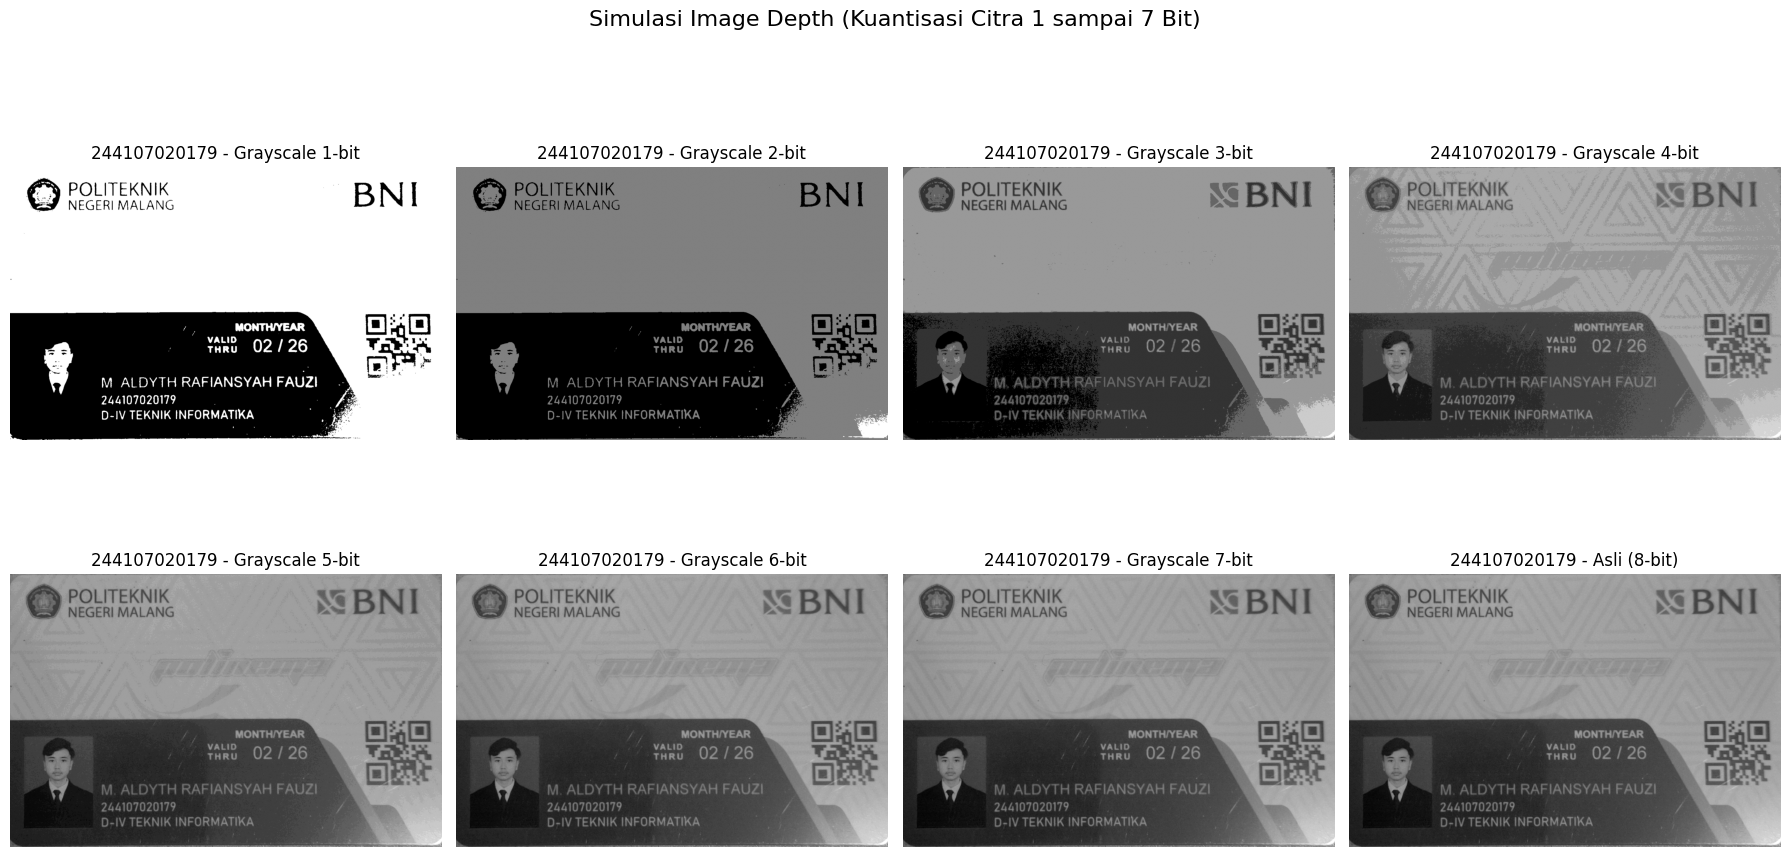

In [32]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

path_b = '/content/drive/MyDrive/PCVK2026/KTM1b.jpg'
original = cv2.imread(path_b, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(18, 10))

for bit_depth in range(1, 8):
    # Rumus kuantisasi level dan citra depth
    level = 255 / (np.power(2, bit_depth) - 1)

    # Proses kuantisasi piksel
    depth_image = np.round(original / level) * level
    depth_image = depth_image.astype(np.uint8)

    # Tampilkan menggunakan subplot (2 baris, 4 kolom)
    plt.subplot(2, 4, bit_depth)
    plt.imshow(depth_image, cmap='gray')
    plt.title(f'{NIM} - Grayscale {bit_depth}-bit')
    plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(original, cmap='gray')
plt.title(f'{NIM} - Asli (8-bit)')
plt.axis('off')

plt.suptitle('Simulasi Image Depth (Kuantisasi Citra 1 sampai 7 Bit)', fontsize=16)
plt.tight_layout()
plt.show()

> Nama dan NIM baru mulai terbaca dengan jelas pada kedalaman 4-bit hingga 7-bit

8. Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob). Dengan menggunakan code diatas, anda tinggal memanggil image difolder tersebut
menggunakan cv_img[0], cv_img[1], dst.

Jumlah citra noise yang berhasil dimuat: 100


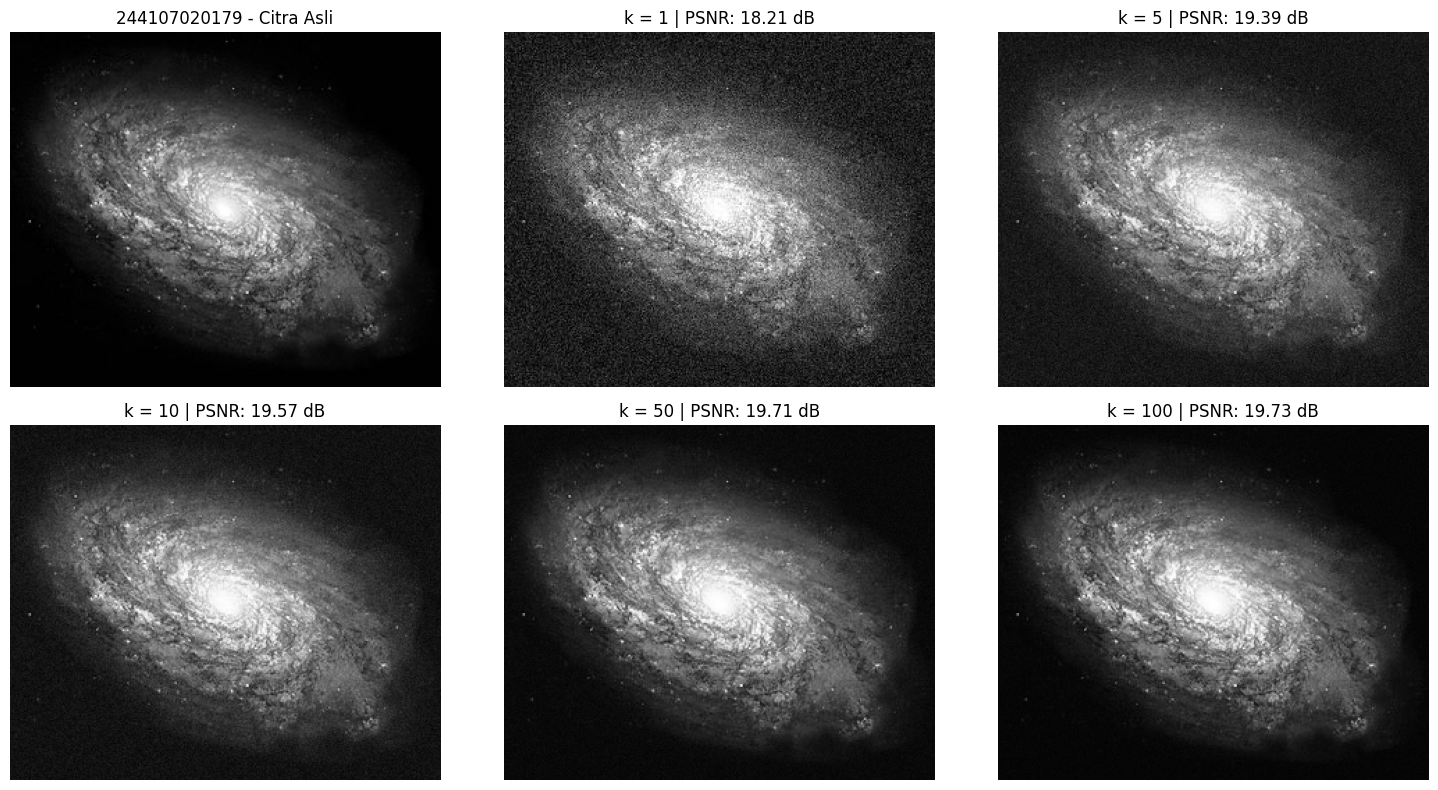


Tabel Hasil PSNR Average Denoising:


,Jumlah Citra (k),PSNR (dB)
0,1,18.209999
1,5,19.389999
2,10,19.570000
3,25,19.680000
4,50,19.709999
5,100,19.730000


In [33]:
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path_galaxy = '/content/drive/MyDrive/PCVK2026/galaxy.jpg'
img_asli = cv2.imread(path_galaxy, cv2.IMREAD_GRAYSCALE)

cv_img = []
for img_path in glob.glob('/content/drive/MyDrive/PCVK2026/noises/*.jpg'):
    n = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if n is not None:
        cv_img.append(n.astype(np.float32))

print(f"Jumlah citra noise yang berhasil dimuat: {len(cv_img)}")

# Fungsi untuk menghitung nilai PSNR
def hitung_psnr(img_asli, img_noise_atau_denoised):
    img_asli = img_asli.astype(np.float32)
    mse = np.mean((img_asli - img_noise_atau_denoised) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# Simulasi Average Denoising secara bertahap (akumulasi jumlah citra: 1, 5, 10, 25, 50, 100)
jumlah_sampel = [1, 5, 10, 25, 50, len(cv_img)]
hasil_eksperimen = []

plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(img_asli, cmap='gray')
plt.title(f'{NIM} - Citra Asli')
plt.axis('off')

plot_idx = 2
for idx, k in enumerate(jumlah_sampel):
    if k > len(cv_img):
        continue

    # Ambil k citra pertama lalu rata-ratakan (Average Denoising)
    subset_img = cv_img[:k]
    img_denoised = np.mean(subset_img, axis=0)

    # Hitung PSNR antara citra asli dan hasil denoised
    psnr_val = hitung_psnr(img_asli, img_denoised)

    hasil_eksperimen.append({
        'Jumlah Citra (k)': k,
        'PSNR (dB)': round(psnr_val, 2)
    })

    # Tampilkan beberapa sampel visual
    if k in [1, 5, 10, 50, len(cv_img)]:
        plt.subplot(2, 3, plot_idx)
        plt.imshow(np.clip(img_denoised, 0, 255).astype(np.uint8), cmap='gray')
        plt.title(f'k = {k} | PSNR: {psnr_val:.2f} dB')
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

df_psnr = pd.DataFrame(hasil_eksperimen)
print("\nTabel Hasil PSNR Average Denoising:")
display(df_psnr)

Jawaban no 8

- Semakin banyak jumlah citra ber noise yang dirata-ratakan (k semakin besar yang mendekati 100), maka nilai PSNR akan semakin meningkat.
- Penambahan jumlah citra terbukti efektif meredam Gaussian Noise (karena sifat derau acak/random bernilai rata-rata nol akan saling meniadakan saat dijumlahkan dan dirata-rata). Akibatnya, detail objek galaksi menjadi jauh lebih tajam dan bersih dari bintik-bintik pengganggu.

9. Buat mask biner Anda sendiri yang menutup area foto wajah dan area NIM pada
KTM1d.jpg, lalu gabungkan dengan citra menggunakan operator AND sehingga kedua
area tersebut tersamarkan. Tuliskan koordinat kotak mask yang Anda pakai.

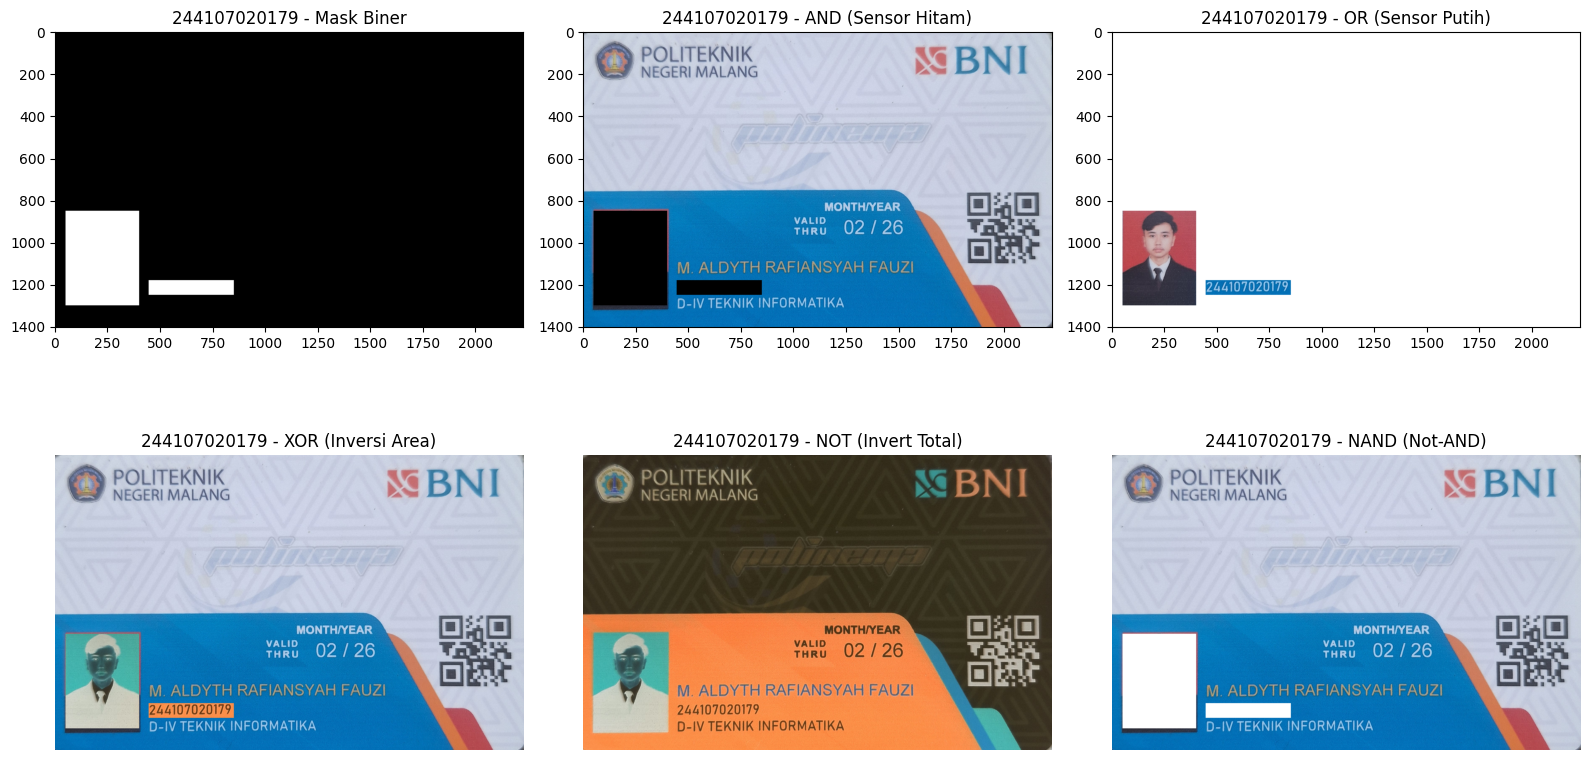

In [59]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

path_d = '/content/drive/MyDrive/PCVK2026/KTM1d.jpg'
img_bgr = cv2.imread(path_d)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

# Mask Biner kosong dengan 2 Kotak Terpisah (Foto & NIM)
mask = np.zeros((h, w), dtype=np.uint8)

# Kotak 1: Area Foto Wajah
mask[850:1300, 50:400] = 255

# Kotak 2: Area Teks NIM
mask[1180:1250, 445:850] = 255

# Konversi mask ke 3-channel agar kompatibel dengan citra RGB
mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)

# Operasi Logika Bitwise
out_and = cv2.bitwise_and(img_rgb, cv2.bitwise_not(mask_3ch))
out_or_style = np.where(mask_3ch == 255, img_rgb, 255)
out_xor = cv2.bitwise_xor(img_rgb, mask_3ch)
out_not = cv2.bitwise_not(img_rgb)
out_nand_style = np.where(mask_3ch == 255, 255, img_rgb)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Mask Biner (Menunjukkan dua kotak terpisah)
axes[0, 0].imshow(mask, cmap='gray')
axes[0, 0].set_title(f'{NIM} - Mask Biner')
axes[0, 0].axis('on')

# 2. AND (Sensor Hitam)
axes[0, 1].imshow(out_and)
axes[0, 1].set_title(f'{NIM} - AND (Sensor Hitam)')
axes[0, 1].axis('on')

# 3. OR (Sensor Putih)
axes[0, 2].imshow(out_or_style)
axes[0, 2].set_title(f'{NIM} - OR (Sensor Putih)')
axes[0, 2].axis('on')

# 4. XOR (Inversi Area)
axes[1, 0].imshow(out_xor)
axes[1, 0].set_title(f'{NIM} - XOR (Inversi Area)')
axes[1, 0].axis('off')

# 5. NOT (Invert Total)
axes[1, 1].imshow(out_not)
axes[1, 1].set_title(f'{NIM} - NOT (Invert Total)')
axes[1, 1].axis('off')

# 6. NAND (Not-AND)
axes[1, 2].imshow(out_nand_style)
axes[1, 2].set_title(f'{NIM} - NAND (Not-AND)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Hasil analisa

- AND (Sensor Hitam): Menyamarkan area target menjadi hitam pekat karena piksel dikalikan dengan nilai 0 (hitam) dari mask.
- OR (Sensor Putih): Mengubah area target menjadi putih penuh dan menyembunyikan latar belakang lainnya karena digabungkan dengan nilai maksimal (255).
- XOR (Inversi Area): Membalikkan warna (negatif) secara khusus hanya pada area yang ditunjuk oleh mask biner.
- NOT (Invert Total): Membalikkan seluruh warna citra secara menyeluruh di seluruh bagian gambar (0 - 255).
- NAND (Not-AND): Kebalikan dari operasi AND, di mana area mask berubah menjadi putih bersih (sensor putih) sementara area luar kartu tetap seperti semula.

10. Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang
sebenarnya cukup baik. Pilih salah satu metode berikut dan implementasikan pada foto
tersebut (Linear Brightness, Contrast, Logarithmic Brightness, Gamma Correction). Sebutkan
alasan dan resiko metode yang Anda gunakan.

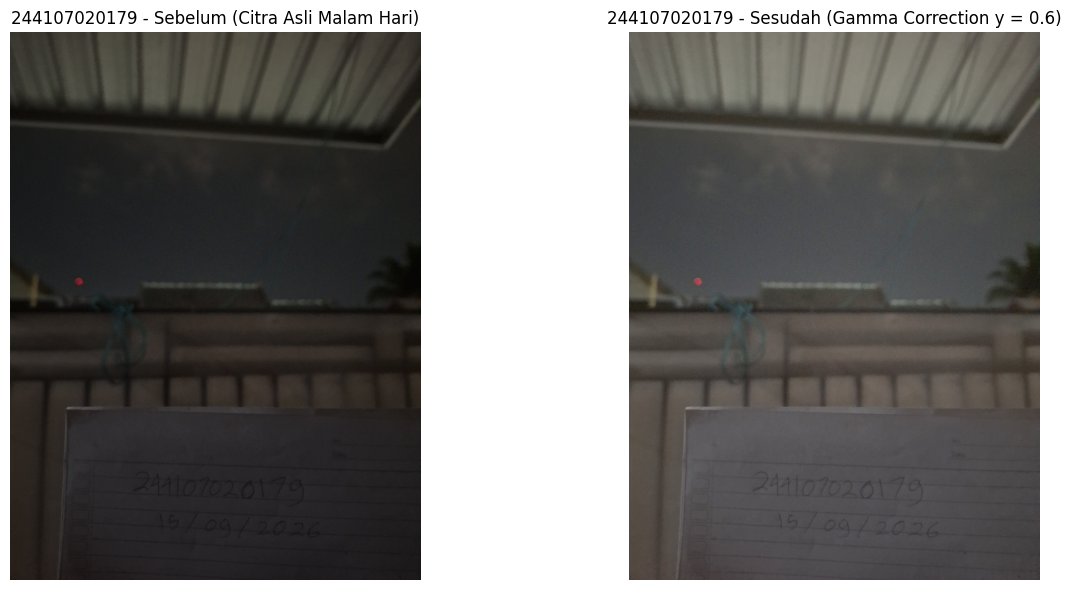

In [67]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

path_night = '/content/drive/MyDrive/PCVK2026/NIGHT1.jpg'
img_bgr = cv2.imread(path_night)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Fungsi Gamma Correction
def apply_gamma(image, gamma):
    img_float = image.astype(np.float32) / 255.0
    img_gamma = np.power(img_float, gamma)
    img_gamma = np.clip(img_gamma * 255.0, 0, 255).astype(np.uint8)
    return img_gamma

best_gamma = 0.6
img_enhanced = apply_gamma(img_rgb, best_gamma)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(f'{NIM} - Sebelum (Citra Asli Malam Hari)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_enhanced)
plt.title(f'{NIM} - Sesudah (Gamma Correction y = {best_gamma})')
plt.axis('off')

plt.tight_layout()
plt.show()

* **Metode yang Dipilih:** Gamma Correction dengan nilai $\gamma = 0.6$.
* **Alasan Pemilihan:** Karena citra malam hari memerlukan penyesuaian non-linier untuk mengangkat detail pada area bayangan tanpa membuat keseluruhan gambar kehilangan kontras aslinya.
* **Penentuan Parameter Terbaik:** Menggunakan parameter $\gamma = 0.6$ karena merupakan titik optimal untuk mencerahkan area gelap secara pas, sehingga tidak terjadi *overexposure* (terlalu terang) seperti pada nilai gamma yang terlalu kecil.
* **Risiko Metode:** Jika nilai gamma diatur terlalu kecil (mendekati 0), citra akan menjadi *overexposure*, tampak pucat, dan langit malam kehilangan warna gelap alaminya.